In [33]:
# Install required packages (run once)
# !pip install requests pandas python-dotenv matplotlib seaborn

In [34]:
import requests
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import time
import os
from dotenv import load_dotenv
import json

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


In [35]:
# Load environment variables
load_dotenv('../.env')

# Configuration
API_KEY = os.getenv('OPENWEATHER_API_KEY', "")

# Islamabad, Pakistan coordinates
LAT = 33.6844
LON = 73.0479

print(f"📍 Location: Islamabad, Pakistan")
print(f"📍 Coordinates: Lat={LAT}, Lon={LON}")
print(f"🔑 API Key configured: {'Yes ✅' if API_KEY != 'your_api_key_here' else 'No ❌ - Please set OPENWEATHER_API_KEY'}")
print(f"🔑 API Key (masked): {API_KEY[:8]}...{API_KEY[-4:]}")

📍 Location: Islamabad, Pakistan
📍 Coordinates: Lat=33.6844, Lon=73.0479
🔑 API Key configured: Yes ✅
🔑 API Key (masked): 834e7cff...6c96


---
## 2. EXTRACT: Test API Connections

### 2.1 Test One Call 3.0 API (Weather Data)

In [36]:
# One Call 3.0 API - Current Weather
ONECALL_URL = "https://api.openweathermap.org/data/3.0/onecall"

def test_onecall_current():
    """Test One Call 3.0 API for current weather data."""
    params = {
        'lat': LAT,
        'lon': LON,
        'appid': API_KEY,
        'units': 'metric',
        'exclude': 'minutely,hourly,daily,alerts'
    }
    
    try:
        response = requests.get(ONECALL_URL, params=params, timeout=10)
        print(f"Status Code: {response.status_code}")
        
        if response.status_code == 200:
            data = response.json()
            print("\n✅ One Call 3.0 API - SUCCESS!")
            return data
        else:
            print(f"\n❌ Error: {response.json()}")
            return None
    except Exception as e:
        print(f"\n❌ Exception: {e}")
        return None

weather_response = test_onecall_current()

Status Code: 200

✅ One Call 3.0 API - SUCCESS!


In [37]:
# Inspect weather response structure
if weather_response:
    print("📊 Weather Response Structure:")
    print(json.dumps(weather_response, indent=2))
else:
    print("⚠️ No weather data to display. Check API key.")

📊 Weather Response Structure:
{
  "lat": 33.6844,
  "lon": 73.0479,
  "timezone": "Asia/Karachi",
  "timezone_offset": 18000,
  "current": {
    "dt": 1776879255,
    "sunrise": 1776817752,
    "sunset": 1776865392,
    "temp": 27.68,
    "feels_like": 28.52,
    "pressure": 1006,
    "humidity": 55,
    "dew_point": 17.83,
    "uvi": 0,
    "clouds": 49,
    "visibility": 10000,
    "wind_speed": 2.33,
    "wind_deg": 21,
    "wind_gust": 2.33,
    "weather": [
      {
        "id": 802,
        "main": "Clouds",
        "description": "scattered clouds",
        "icon": "03n"
      }
    ]
  }
}


In [38]:
# Extract weather features from response
def parse_weather_current(data):
    """Parse current weather data from One Call 3.0 API."""
    if not data or 'current' not in data:
        return None
    
    current = data['current']
    
    weather_features = {
        'unix_time': current.get('dt'),
        'datetime': datetime.utcfromtimestamp(current.get('dt')),
        'temp': current.get('temp'),
        'feels_like': current.get('feels_like'),
        'humidity': current.get('humidity'),
        'pressure': current.get('pressure'),
        'wind_speed': current.get('wind_speed'),
        'wind_deg': current.get('wind_deg'),
        'clouds': current.get('clouds'),
        'visibility': current.get('visibility'),
        'dew_point': current.get('dew_point'),
        'uvi': current.get('uvi'),
    }
    
    return weather_features

if weather_response:
    weather_features = parse_weather_current(weather_response)
    print("🌤️ Extracted Weather Features:")
    for key, value in weather_features.items():
        print(f"  {key}: {value}")

🌤️ Extracted Weather Features:
  unix_time: 1776879255
  datetime: 2026-04-22 17:34:15
  temp: 27.68
  feels_like: 28.52
  humidity: 55
  pressure: 1006
  wind_speed: 2.33
  wind_deg: 21
  clouds: 49
  visibility: 10000
  dew_point: 17.83
  uvi: 0


### 2.2 Test Air Pollution API (Pollutant Data)

In [39]:
# Air Pollution API - Current
POLLUTION_URL = "http://api.openweathermap.org/data/2.5/air_pollution"

def test_pollution_current():
    """Test Air Pollution API for current pollution data."""
    params = {
        'lat': LAT,
        'lon': LON,
        'appid': API_KEY
    }
    
    try:
        response = requests.get(POLLUTION_URL, params=params, timeout=10)
        print(f"Status Code: {response.status_code}")
        
        if response.status_code == 200:
            data = response.json()
            print("\n✅ Air Pollution API - SUCCESS!")
            return data
        else:
            print(f"\n❌ Error: {response.json()}")
            return None
    except Exception as e:
        print(f"\n❌ Exception: {e}")
        return None

pollution_response = test_pollution_current()

Status Code: 200

✅ Air Pollution API - SUCCESS!


In [40]:
# Inspect pollution response structure
if pollution_response:
    print("📊 Pollution Response Structure:")
    print(json.dumps(pollution_response, indent=2))
else:
    print("⚠️ No pollution data to display. Check API key.")

📊 Pollution Response Structure:
{
  "coord": {
    "lon": 73.0479,
    "lat": 33.6844
  },
  "list": [
    {
      "main": {
        "aqi": 4
      },
      "components": {
        "co": 530.69,
        "no": 0,
        "no2": 18.06,
        "o3": 75.52,
        "so2": 3.2,
        "pm2_5": 50.94,
        "pm10": 122.35,
        "nh3": 43.99
      },
      "dt": 1776879164
    }
  ]
}


In [41]:
# Extract pollution features from response
def parse_pollution_current(data):
    """Parse current pollution data from Air Pollution API."""
    if not data or 'list' not in data or len(data['list']) == 0:
        return None
    
    item = data['list'][0]
    components = item.get('components', {})
    main = item.get('main', {})
    
    pollution_features = {
        'unix_time': item.get('dt'),
        'datetime': datetime.utcfromtimestamp(item.get('dt')),
        'aqi': main.get('aqi'),  # 1-5 scale
        'pm2_5': components.get('pm2_5'),
        'pm10': components.get('pm10'),
        'no2': components.get('no2'),
        'so2': components.get('so2'),
        'co': components.get('co'),
        'o3': components.get('o3'),
        'nh3': components.get('nh3'),
        'no': components.get('no'),
    }
    
    return pollution_features

if pollution_response:
    pollution_features = parse_pollution_current(pollution_response)
    print("🏭 Extracted Pollution Features:")
    for key, value in pollution_features.items():
        print(f"  {key}: {value}")

🏭 Extracted Pollution Features:
  unix_time: 1776879164
  datetime: 2026-04-22 17:32:44
  aqi: 4
  pm2_5: 50.94
  pm10: 122.35
  no2: 18.06
  so2: 3.2
  co: 530.69
  o3: 75.52
  nh3: 43.99
  no: 0


### 2.3 Test Historical Data APIs

In [42]:
# One Call 3.0 Time Machine API - Historical Weather

TIMEMACHINE_URL = "https://api.openweathermap.org/data/3.0/onecall/timemachine"

def fetch_historical_weather(target_date):
    """Fetch historical weather data for a specific date."""
    unix_ts = int(target_date.timestamp())
    
    params = {
        'lat': LAT,
        'lon': LON,
        'dt': unix_ts,
        'appid': API_KEY,
        'units': 'metric'
    }
    
    try:
        response = requests.get(TIMEMACHINE_URL, params=params, timeout=10)
        if response.status_code == 200:
            return response.json()
        else:
            print(f"❌ Error: {response.status_code} - {response.text}")
            return None
    except Exception as e:
        print(f"❌ Exception: {e}")
        return None

# Test with yesterday's date
yesterday = datetime.now() - timedelta(days=1)
print(f"📅 Fetching historical weather for: {yesterday.strftime('%Y-%m-%d')}")

hist_weather = fetch_historical_weather(yesterday)
if hist_weather:
    print("✅ Historical weather data fetched successfully!")
    print(f"\nData keys: {hist_weather.keys()}")

📅 Fetching historical weather for: 2026-04-21
✅ Historical weather data fetched successfully!

Data keys: dict_keys(['lat', 'lon', 'timezone', 'timezone_offset', 'data'])


In [43]:
# Air Pollution History API
POLLUTION_HISTORY_URL = "http://api.openweathermap.org/data/2.5/air_pollution/history"

def fetch_historical_pollution(start_date, end_date):
    """Fetch historical pollution data for a date range."""
    start_unix = int(start_date.timestamp())
    end_unix = int(end_date.timestamp())
    
    params = {
        'lat': LAT,
        'lon': LON,
        'start': start_unix,
        'end': end_unix,
        'appid': API_KEY
    }
    
    try:
        response = requests.get(POLLUTION_HISTORY_URL, params=params, timeout=10)
        if response.status_code == 200:
            return response.json()
        else:
            print(f"❌ Error: {response.status_code} - {response.text}")
            return None
    except Exception as e:
        print(f"❌ Exception: {e}")
        return None

# Test with last 3 days
end_date = datetime.now()
start_date = end_date - timedelta(days=3)
print(f"📅 Fetching pollution history: {start_date.strftime('%Y-%m-%d')} to {end_date.strftime('%Y-%m-%d')}")

hist_pollution = fetch_historical_pollution(start_date, end_date)
if hist_pollution:
    print(f"✅ Historical pollution data fetched successfully!")
    print(f"📊 Number of records: {len(hist_pollution.get('list', []))}")

📅 Fetching pollution history: 2026-04-19 to 2026-04-22
✅ Historical pollution data fetched successfully!
📊 Number of records: 72


In [44]:
# ============================================================
# SECTION 2.4 — Fetch 3 Years of FREE Historical Data
# Uses Open-Meteo API — NO API KEY REQUIRED
# ============================================================

import requests
import pandas as pd
from datetime import datetime

def fetch_openmeteo_full_history(start_date="2022-01-01", end_date="2024-12-31"):
    """
    Fetch FREE 3-year historical air quality data from Open-Meteo.
    No API key needed. Covers Islamabad coordinates.
    """
    print(f"📅 Fetching air quality history: {start_date} → {end_date}")
    
    url = "https://air-quality-api.open-meteo.com/v1/air-quality"
    params = {
        "latitude": 33.6844,       # Islamabad
        "longitude": 73.0479,
        "hourly": ["pm2_5", "pm10", "nitrogen_dioxide", "ozone", "carbon_monoxide"],
        "start_date": start_date,
        "end_date": end_date,
        "timezone": "Asia/Karachi"
    }
    
    response = requests.get(url, params=params, timeout=30)
    if response.status_code != 200:
        print(f"❌ Air quality error: {response.status_code}")
        return None
    
    aq_data = response.json()
    aq_df = pd.DataFrame(aq_data["hourly"])
    aq_df = aq_df.rename(columns={
        "time": "datetime",
        "nitrogen_dioxide": "no2",
        "ozone": "o3",
        "carbon_monoxide": "co"
    })
    aq_df["datetime"] = pd.to_datetime(aq_df["datetime"])
    print(f"✅ Air quality records: {len(aq_df)}")
    
    # --- Weather history (also free) ---
    print(f"📅 Fetching weather history: {start_date} → {end_date}")
    
    w_url = "https://archive-api.open-meteo.com/v1/archive"
    w_params = {
        "latitude": 33.6844,
        "longitude": 73.0479,
        "hourly": [
            "temperature_2m", "relative_humidity_2m",
            "wind_speed_10m", "wind_direction_10m",
            "surface_pressure", "dew_point_2m", "cloud_cover"
        ],
        "start_date": start_date,
        "end_date": end_date,
        "timezone": "Asia/Karachi"
    }
    
    w_response = requests.get(w_url, params=w_params, timeout=30)
    if w_response.status_code != 200:
        print(f"❌ Weather error: {w_response.status_code}")
        return None
    
    w_data = w_response.json()
    w_df = pd.DataFrame(w_data["hourly"])
    w_df = w_df.rename(columns={
        "time": "datetime",
        "temperature_2m": "temp",
        "relative_humidity_2m": "humidity",
        "wind_speed_10m": "wind_speed",
        "wind_direction_10m": "wind_deg",
        "surface_pressure": "pressure",
        "dew_point_2m": "dew_point",
        "cloud_cover": "clouds"
    })
    w_df["datetime"] = pd.to_datetime(w_df["datetime"])
    print(f"✅ Weather records: {len(w_df)}")
    
    # --- Merge both ---
    merged = pd.merge(aq_df, w_df, on="datetime", how="inner")
    merged = merged.dropna(subset=["pm2_5"]).reset_index(drop=True)
    
    print(f"\n✅ MERGED HISTORICAL DATASET")
    print(f"   Records : {len(merged)}")
    print(f"   From    : {merged['datetime'].min()}")
    print(f"   To      : {merged['datetime'].max()}")
    print(f"   Columns : {list(merged.columns)}")
    return merged


# Fetch 3 years (2020-2026)
historical_df = fetch_openmeteo_full_history("2020-01-01", "2026-03-31")

# Save it
if historical_df is not None:
    historical_df.to_csv("../data/raw/historical_aqi_2020_2026.csv", index=False)
    print("\n💾 Saved to: ../data/raw/historical_aqi_2020_2026.csv")

📅 Fetching air quality history: 2020-01-01 → 2026-03-31
✅ Air quality records: 54768
📅 Fetching weather history: 2020-01-01 → 2026-03-31
✅ Weather records: 54768

✅ MERGED HISTORICAL DATASET
   Records : 32059
   From    : 2022-08-04 05:00:00
   To      : 2026-03-31 23:00:00
   Columns : ['datetime', 'pm2_5', 'pm10', 'no2', 'o3', 'co', 'temp', 'humidity', 'wind_speed', 'wind_deg', 'pressure', 'dew_point', 'clouds']

💾 Saved to: ../data/raw/historical_aqi_2020_2026.csv


In [45]:
# ============================================================
# SECTION 2.5 — Combine Historical + Live Data
# ============================================================
import pandas as pd
import os

# Load historical (already fetched and saved in 2.4)
hist = pd.read_csv("../data/raw/historical_aqi_2020_2026.csv", parse_dates=["datetime"])
print(f"✅ Historical loaded: {len(hist)} records ({hist['datetime'].min().date()} → {hist['datetime'].max().date()})")

# Try to use merged_data if it exists, otherwise skip live data for now
try:
    live = merged_data.copy()
    live_available = True
    print(f"✅ Live data available: {len(live)} records")
except NameError:
    live_available = False
    print("⚠️  merged_data not in memory — using historical only for now")
    print("    (Run Section 5 fetch_and_merge_data() later to add live data)")

# Combine
if live_available:
    full_dataset = pd.concat([hist, live], ignore_index=True)
else:
    full_dataset = hist.copy()

full_dataset = full_dataset.drop_duplicates(subset="datetime").sort_values("datetime").reset_index(drop=True)

# Save as the main training file
os.makedirs("../data/raw", exist_ok=True)
full_dataset.to_csv("../data/raw/aqi_training_data.csv", index=False)

print(f"\n✅ FULL DATASET SAVED")
print(f"   Records : {len(full_dataset)}")
print(f"   From    : {full_dataset['datetime'].min()}")
print(f"   To      : {full_dataset['datetime'].max()}")
print(f"   Columns : {list(full_dataset.columns)}")

# Also set as merged_data so rest of notebook works
merged_data = full_dataset
print(f"\n✅ merged_data is now set to the full 6-year dataset!")

✅ Historical loaded: 32059 records (2022-08-04 → 2026-03-31)
✅ Live data available: 28 records

✅ FULL DATASET SAVED
   Records : 32087
   From    : 2022-08-04 05:00:00
   To      : 2026-04-21 17:33:16
   Columns : ['datetime', 'pm2_5', 'pm10', 'no2', 'o3', 'co', 'temp', 'humidity', 'wind_speed', 'wind_deg', 'pressure', 'dew_point', 'clouds', 'unix_time', 'hour_ts', 'feels_like', 'visibility', 'uvi', 'aqi', 'so2', 'nh3', 'no']

✅ merged_data is now set to the full 6-year dataset!


---
## 3. TRANSFORM: Data Processing & Merging

In [46]:
def parse_historical_weather(data):
    """Parse historical weather data into a DataFrame."""
    if not data or 'data' not in data:
        return pd.DataFrame()
    
    records = []
    for item in data['data']:
        record = {
            'unix_time': item.get('dt'),
            'temp': item.get('temp'),
            'feels_like': item.get('feels_like'),
            'humidity': item.get('humidity'),
            'pressure': item.get('pressure'),
            'wind_speed': item.get('wind_speed'),
            'wind_deg': item.get('wind_deg'),
            'clouds': item.get('clouds'),
            'visibility': item.get('visibility'),
            'dew_point': item.get('dew_point'),
            'uvi': item.get('uvi'),
        }
        records.append(record)
    
    df = pd.DataFrame(records)
    if not df.empty:
        df['datetime'] = pd.to_datetime(df['unix_time'], unit='s')
        # Round to nearest hour for merging
        df['hour_ts'] = (df['unix_time'] // 3600) * 3600
    
    return df

# Parse historical weather
if hist_weather:
    weather_df = parse_historical_weather(hist_weather)
    print(f"🌤️ Weather DataFrame Shape: {weather_df.shape}")
    display(weather_df.head())

🌤️ Weather DataFrame Shape: (1, 13)


,unix_time,temp,feels_like,humidity,pressure,wind_speed,wind_deg,clouds,visibility,dew_point,uvi,datetime,hour_ts
0,1776792892,25.32,24.72,31,1008,2.09,12,25,10000,6.99,0,2026-04-21 17:34:52,1776790800


In [47]:
def parse_historical_pollution(data):
    """Parse historical pollution data into a DataFrame."""
    if not data or 'list' not in data:
        return pd.DataFrame()
    
    records = []
    for item in data['list']:
        components = item.get('components', {})
        main = item.get('main', {})
        
        record = {
            'unix_time': item.get('dt'),
            'aqi': main.get('aqi'),
            'pm2_5': components.get('pm2_5'),
            'pm10': components.get('pm10'),
            'no2': components.get('no2'),
            'so2': components.get('so2'),
            'co': components.get('co'),
            'o3': components.get('o3'),
            'nh3': components.get('nh3'),
            'no': components.get('no'),
        }
        records.append(record)
    
    df = pd.DataFrame(records)
    if not df.empty:
        df['datetime'] = pd.to_datetime(df['unix_time'], unit='s')
        # Round to nearest hour for merging
        df['hour_ts'] = (df['unix_time'] // 3600) * 3600
    
    return df

# Parse historical pollution
if hist_pollution:
    pollution_df = parse_historical_pollution(hist_pollution)
    print(f"🏭 Pollution DataFrame Shape: {pollution_df.shape}")
    display(pollution_df.head())

🏭 Pollution DataFrame Shape: (72, 12)


,unix_time,aqi,pm2_5,pm10,no2,so2,co,o3,nh3,no,datetime,hour_ts
0,1776621600,3,22.17,57.77,15.52,1.42,452.75,57.51,36.99,0.0,2026-04-19 18:00:00,1776621600
1,1776625200,3,23.06,59.10,15.56,1.38,464.69,53.27,41.98,0.0,2026-04-19 19:00:00,1776625200
2,1776628800,3,24.48,61.05,14.70,1.33,467.61,50.90,45.02,0.0,2026-04-19 20:00:00,1776628800
3,1776632400,3,25.73,62.57,13.48,1.29,465.98,49.59,47.17,0.0,2026-04-19 21:00:00,1776632400
4,1776636000,3,26.84,63.82,11.99,1.23,455.78,49.17,48.19,0.0,2026-04-19 22:00:00,1776636000


In [48]:
def merge_weather_pollution(weather_df, pollution_df):
    """
    Merge weather and pollution data by hour timestamp.
    This creates the complete feature set for ML training.
    """
    if weather_df.empty or pollution_df.empty:
        print("⚠️ One or both DataFrames are empty!")
        return pd.DataFrame()
    
    # Merge on hour_ts
    merged_df = pd.merge(
        weather_df,
        pollution_df,
        on='hour_ts',
        how='inner',
        suffixes=('_weather', '_pollution')
    )
    
    # Clean up duplicate columns
    if 'unix_time_weather' in merged_df.columns:
        merged_df['unix_time'] = merged_df['unix_time_weather']
        merged_df = merged_df.drop(['unix_time_weather', 'unix_time_pollution'], axis=1, errors='ignore')
    
    if 'datetime_weather' in merged_df.columns:
        merged_df['datetime'] = merged_df['datetime_weather']
        merged_df = merged_df.drop(['datetime_weather', 'datetime_pollution'], axis=1, errors='ignore')
    
    # Reorder columns
    cols_order = ['datetime', 'unix_time', 'hour_ts', 
                  'temp', 'feels_like', 'humidity', 'pressure', 'wind_speed', 'wind_deg',
                  'clouds', 'visibility', 'dew_point', 'uvi',
                  'aqi', 'pm2_5', 'pm10', 'no2', 'so2', 'co', 'o3', 'nh3', 'no']
    
    cols_present = [c for c in cols_order if c in merged_df.columns]
    merged_df = merged_df[cols_present]
    
    return merged_df

print("🔗 This function will be used once we have matching data from both APIs.")

🔗 This function will be used once we have matching data from both APIs.


---
## 4. Complete ETL Pipeline Test

In [49]:
def fetch_and_merge_data(num_days=7):
    """
    Complete ETL pipeline to fetch and merge weather + pollution data.
    
    Args:
        num_days: Number of historical days to fetch
        
    Returns:
        DataFrame with merged weather and pollution features
    """
    print(f"\n{'='*60}")
    print(f"🚀 Starting ETL Pipeline for {num_days} days")
    print(f"{'='*60}\n")
    
    all_weather = []
    all_pollution = []
    
    end_date = datetime.now()
    start_date = end_date - timedelta(days=num_days)
    
    # Step 1: Fetch Weather Data (day by day for Time Machine API)
    print("📡 Step 1: Extracting Weather Data...")
    for day_offset in range(num_days):
        target_date = end_date - timedelta(days=day_offset+1)
        print(f"  Fetching weather for {target_date.strftime('%Y-%m-%d')}...", end=" ")
        
        weather_data = fetch_historical_weather(target_date)
        if weather_data:
            df = parse_historical_weather(weather_data)
            if not df.empty:
                all_weather.append(df)
                print(f"✅ ({len(df)} records)")
            else:
                print("⚠️ No data")
        else:
            print("❌ Failed")
        
        time.sleep(0.5)  # Rate limiting
    
    # Step 2: Fetch Pollution Data (range query)
    print(f"\n📡 Step 2: Extracting Pollution Data...")
    pollution_data = fetch_historical_pollution(start_date, end_date)
    if pollution_data:
        pollution_df = parse_historical_pollution(pollution_data)
        if not pollution_df.empty:
            print(f"  ✅ Pollution data: {len(pollution_df)} records")
            all_pollution.append(pollution_df)
    
    # Step 3: Combine and Merge
    print(f"\n🔧 Step 3: Transforming & Merging Data...")
    
    if all_weather:
        weather_df = pd.concat(all_weather, ignore_index=True)
        print(f"  Weather records: {len(weather_df)}")
    else:
        weather_df = pd.DataFrame()
        print("  ⚠️ No weather data collected")
    
    if all_pollution:
        pollution_df = pd.concat(all_pollution, ignore_index=True)
        print(f"  Pollution records: {len(pollution_df)}")
    else:
        pollution_df = pd.DataFrame()
        print("  ⚠️ No pollution data collected")
    
    # Merge
    if not weather_df.empty and not pollution_df.empty:
        merged_df = merge_weather_pollution(weather_df, pollution_df)
        print(f"  ✅ Merged records: {len(merged_df)}")
    else:
        merged_df = pd.DataFrame()
        print("  ❌ Cannot merge - missing data")
    
    print(f"\n{'='*60}")
    print(f"✅ ETL Pipeline Complete!")
    print(f"{'='*60}\n")
    
    return merged_df

# Run the pipeline (use small number for testing)
merged_data = fetch_and_merge_data(num_days=30)
print("⚠️ Uncomment the line above to run the full ETL pipeline")


🚀 Starting ETL Pipeline for 30 days

📡 Step 1: Extracting Weather Data...
  Fetching weather for 2026-04-21... ✅ (1 records)
  Fetching weather for 2026-04-20... ✅ (1 records)
  Fetching weather for 2026-04-19... ✅ (1 records)
  Fetching weather for 2026-04-18... ✅ (1 records)
  Fetching weather for 2026-04-17... ✅ (1 records)
  Fetching weather for 2026-04-16... ✅ (1 records)
  Fetching weather for 2026-04-15... ✅ (1 records)
  Fetching weather for 2026-04-14... ✅ (1 records)
  Fetching weather for 2026-04-13... ✅ (1 records)
  Fetching weather for 2026-04-12... ✅ (1 records)
  Fetching weather for 2026-04-11... ✅ (1 records)
  Fetching weather for 2026-04-10... ✅ (1 records)
  Fetching weather for 2026-04-09... ✅ (1 records)
  Fetching weather for 2026-04-08... ✅ (1 records)
  Fetching weather for 2026-04-07... ✅ (1 records)
  Fetching weather for 2026-04-06... ✅ (1 records)
  Fetching weather for 2026-04-05... ✅ (1 records)
  Fetching weather for 2026-04-04... ✅ (1 records)
  Fetch

---
## 5. Data Quality Checks

In [50]:
def data_quality_report(df, name="Dataset"):
    """
    Generate a data quality report for a DataFrame.
    """
    print(f"\n{'='*60}")
    print(f"📊 Data Quality Report: {name}")
    print(f"{'='*60}\n")
    
    print(f"📏 Shape: {df.shape[0]} rows × {df.shape[1]} columns")
    print(f"\n📋 Column Types:")
    print(df.dtypes)
    
    print(f"\n🔍 Missing Values:")
    missing = df.isnull().sum()
    missing_pct = (missing / len(df) * 100).round(2)
    missing_report = pd.DataFrame({
        'Missing': missing,
        'Percentage': missing_pct
    })
    print(missing_report[missing_report['Missing'] > 0])
    
    print(f"\n📈 Numeric Statistics:")
    display(df.describe())
    
    return missing_report

# Example usage (will work once we have data)
quality_report = data_quality_report(merged_data, "Merged AQI Data")
print("⚠️ Run the ETL pipeline first, then call data_quality_report()")


📊 Data Quality Report: Merged AQI Data

📏 Shape: 28 rows × 22 columns

📋 Column Types:
datetime      datetime64[ns]
unix_time              int64
hour_ts                int64
temp                 float64
feels_like           float64
humidity               int64
pressure               int64
wind_speed           float64
wind_deg               int64
clouds                 int64
visibility            object
dew_point            float64
uvi                   object
aqi                    int64
pm2_5                float64
pm10                 float64
no2                  float64
so2                  float64
co                   float64
o3                   float64
nh3                  float64
no                   float64
dtype: object

🔍 Missing Values:
            Missing  Percentage
visibility       23       82.14
uvi              23       82.14

📈 Numeric Statistics:


,datetime,unix_time,hour_ts,temp,feels_like,humidity,pressure,wind_speed,wind_deg,clouds,dew_point,aqi,pm2_5,pm10,no2,so2,co,o3,nh3,no
count,28,2.800000e+01,2.800000e+01,28.000000,28.000000,28.000000,28.00000,28.000000,28.000000,28.000000,28.000000,28.000000,28.000000,28.000000,28.000000,28.000000,28.000000,28.000000,28.000000,28.000000
mean,2026-04-07 18:26:22.714285568,1.775586e+09,1.775584e+09,19.555357,19.296071,66.250000,1011.25000,1.647857,152.642857,56.214286,12.545714,2.500000,21.681786,42.906429,12.922857,1.816071,445.622500,65.066429,25.035000,0.000357
min,2026-03-24 17:34:57,1.774374e+09,1.774372e+09,12.480000,12.160000,31.000000,1006.00000,0.450000,9.000000,0.000000,6.990000,2.000000,10.060000,18.380000,3.390000,0.890000,236.440000,31.890000,2.130000,0.000000
25%,2026-03-31 11:34:57,1.774957e+09,1.774955e+09,17.362500,17.025000,58.750000,1009.00000,1.040000,31.250000,4.750000,11.047500,2.000000,17.755000,31.937500,9.867500,1.370000,408.540000,56.232500,13.385000,0.000000
50%,2026-04-08 05:34:57,1.775626e+09,1.775624e+09,19.525000,19.245000,69.000000,1011.00000,1.570000,98.000000,80.500000,12.630000,2.500000,21.410000,39.890000,12.840000,1.745000,428.990000,63.215000,22.770000,0.000000
75%,2026-04-14 23:34:57,1.776210e+09,1.776208e+09,22.365000,22.225000,76.000000,1013.00000,2.240000,291.750000,100.000000,14.440000,3.000000,24.200000,52.255000,14.940000,2.075000,478.707500,69.655000,31.670000,0.000000
max,2026-04-21 17:34:57,1.776793e+09,1.776791e+09,25.320000,24.720000,91.000000,1017.00000,3.530000,351.000000,100.000000,16.830000,3.000000,32.240000,66.330000,22.280000,3.470000,630.510000,104.670000,65.070000,0.010000
std,NaN,7.489780e+05,7.489780e+05,3.228080,3.202827,16.365331,2.74368,0.773431,129.563716,45.715187,2.594668,0.509175,5.667753,13.240480,4.903225,0.666241,87.982149,16.766117,16.182679,0.001890


⚠️ Run the ETL pipeline first, then call data_quality_report()


---
## 6. Data Visualization

✅ Loaded: 32087 records (2022-08-04 → 2026-04-21)
✅ Charts saved as eda_charts.png


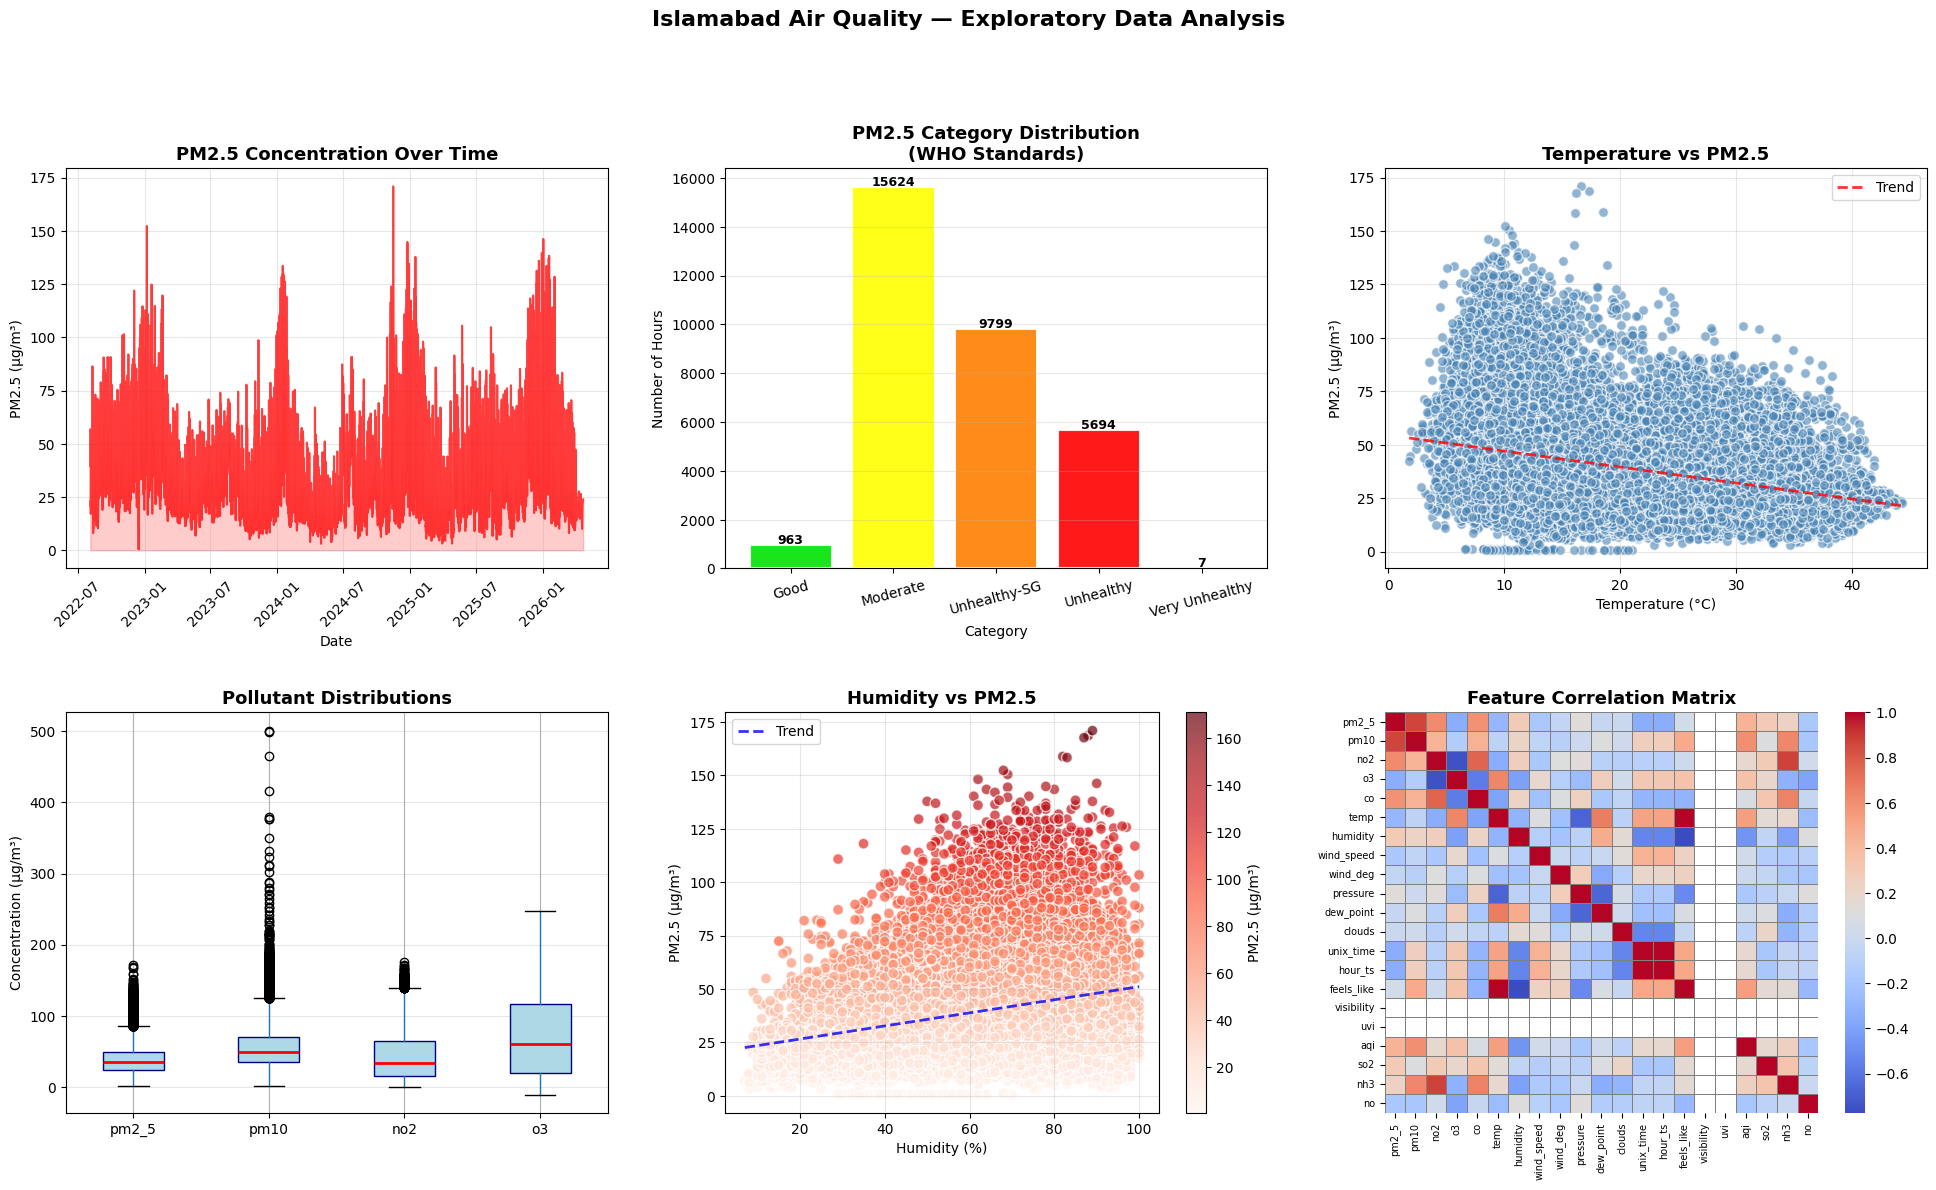

In [57]:
def visualize_aqi_data(df):
    if df.empty:
        print("⚠️ No data to visualize")
        return

    fig, axes = plt.subplots(2, 3, figsize=(20, 12))

    # 1. PM2.5 over time (KEEP AS IS - looks great)
    if 'pm2_5' in df.columns and 'datetime' in df.columns:
        axes[0, 0].plot(df['datetime'], df['pm2_5'], color='red', alpha=0.7, linewidth=1.5)
        axes[0, 0].fill_between(df['datetime'], df['pm2_5'], alpha=0.2, color='red')
        axes[0, 0].set_title('PM2.5 Concentration Over Time', fontsize=13, fontweight='bold')
        axes[0, 0].set_xlabel('Date')
        axes[0, 0].set_ylabel('PM2.5 (μg/m³)')
        axes[0, 0].tick_params(axis='x', rotation=45)
        axes[0, 0].grid(True, alpha=0.3)

    # 2. PM2.5 Category Distribution (WHO standards - works with full dataset)
    def get_pm25_category(val):
        if val <= 12:    return 'Good'
        elif val <= 35:  return 'Moderate'
        elif val <= 55:  return 'Unhealthy-SG'
        elif val <= 150: return 'Unhealthy'
        else:            return 'Very Unhealthy'

    pm25_cats = df['pm2_5'].apply(get_pm25_category)
    cat_counts = pm25_cats.value_counts()
    cat_order = ['Good', 'Moderate', 'Unhealthy-SG', 'Unhealthy', 'Very Unhealthy']
    cat_colors = ['#00e400', '#ffff00', '#ff7e00', '#ff0000', '#8f3f97']
    ordered = [(c, cat_counts.get(c, 0)) for c in cat_order if cat_counts.get(c, 0) > 0]
    labels, values = zip(*ordered)
    bar_colors = [cat_colors[cat_order.index(l)] for l in labels]

    axes[0, 1].bar(labels, values, color=bar_colors, edgecolor='white', linewidth=1.5, alpha=0.9)
    axes[0, 1].set_title('PM2.5 Category Distribution\n(WHO Standards)', fontsize=13, fontweight='bold')
    axes[0, 1].set_xlabel('Category')
    axes[0, 1].set_ylabel('Number of Hours')
    axes[0, 1].tick_params(axis='x', rotation=15)
    axes[0, 1].grid(True, alpha=0.3, axis='y')
    for i, v in enumerate(values):
        axes[0, 1].text(i, v + 50, str(v), ha='center', fontweight='bold', fontsize=9)

    # 3. Temperature vs PM2.5 with trend line (KEEP AS IS)
    if 'temp' in df.columns and 'pm2_5' in df.columns:
        axes[0, 2].scatter(df['temp'], df['pm2_5'], alpha=0.6, c='steelblue', 
                           edgecolors='white', s=50)
        z = np.polyfit(df['temp'].dropna(), df['pm2_5'].dropna(), 1)
        p = np.poly1d(z)
        x_line = np.linspace(df['temp'].min(), df['temp'].max(), 100)
        axes[0, 2].plot(x_line, p(x_line), "r--", alpha=0.8, linewidth=2, label='Trend')
        axes[0, 2].set_title('Temperature vs PM2.5', fontsize=13, fontweight='bold')
        axes[0, 2].set_xlabel('Temperature (°C)')
        axes[0, 2].set_ylabel('PM2.5 (μg/m³)')
        axes[0, 2].legend()
        axes[0, 2].grid(True, alpha=0.3)

    # 4. Pollutant distributions (KEEP AS IS - looks great)
    pollutants = ['pm2_5', 'pm10', 'no2', 'o3']
    pollutants_present = [p for p in pollutants if p in df.columns]
    if pollutants_present:
        df[pollutants_present].boxplot(ax=axes[1, 0], patch_artist=True,
            boxprops=dict(facecolor='lightblue', color='navy'),
            medianprops=dict(color='red', linewidth=2))
        axes[1, 0].set_title('Pollutant Distributions', fontsize=13, fontweight='bold')
        axes[1, 0].set_ylabel('Concentration (μg/m³)')
        axes[1, 0].grid(True, alpha=0.3, axis='y')

    # 5. FIX: PM2.5 vs Humidity (replaces broken hourly chart)
    if 'humidity' in df.columns and 'pm2_5' in df.columns:
        scatter = axes[1, 1].scatter(df['humidity'], df['pm2_5'],
                                      c=df['pm2_5'], cmap='Reds',
                                      alpha=0.7, s=60, edgecolors='white')
        z2 = np.polyfit(df['humidity'].dropna(), df['pm2_5'].dropna(), 1)
        p2 = np.poly1d(z2)
        x2 = np.linspace(df['humidity'].min(), df['humidity'].max(), 100)
        axes[1, 1].plot(x2, p2(x2), "b--", alpha=0.8, linewidth=2, label='Trend')
        plt.colorbar(scatter, ax=axes[1, 1], label='PM2.5 (μg/m³)')
        axes[1, 1].set_title('Humidity vs PM2.5', fontsize=13, fontweight='bold')
        axes[1, 1].set_xlabel('Humidity (%)')
        axes[1, 1].set_ylabel('PM2.5 (μg/m³)')
        axes[1, 1].legend()
        axes[1, 1].grid(True, alpha=0.3)

    # 6. Correlation heatmap (KEEP AS IS)
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    corr_matrix = df[numeric_cols].corr()
    sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', ax=axes[1, 2],
                xticklabels=True, yticklabels=True,
                linewidths=0.5, linecolor='gray')
    axes[1, 2].set_title('Feature Correlation Matrix', fontsize=13, fontweight='bold')
    axes[1, 2].tick_params(axis='x', rotation=90, labelsize=7)
    axes[1, 2].tick_params(axis='y', rotation=0, labelsize=7)

    plt.suptitle('Islamabad Air Quality — Exploratory Data Analysis',
                 fontsize=16, fontweight='bold', y=1.01)
    plt.tight_layout(pad=3.0)
    plt.savefig('eda_charts.png', dpi=200, bbox_inches='tight')
    print("✅ Charts saved as eda_charts.png")
    plt.show()

# Reload full dataset
# Add PM2.5 AQI category based on WHO standards
def assign_pm25_category(pm25):
    if pm25 <= 12:   return 'Good'
    elif pm25 <= 35: return 'Moderate'
    elif pm25 <= 55: return 'Unhealthy-SG'
    elif pm25 <= 150: return 'Unhealthy'
    else:             return 'Very Unhealthy'

merged_data['aqi_category'] = merged_data['pm2_5'].apply(assign_pm25_category)
merged_data['aqi'] = merged_data['aqi_category']  # so the chart picks it up

merged_data = pd.read_csv("../data/raw/aqi_training_data.csv", parse_dates=["datetime"])
print(f"✅ Loaded: {len(merged_data)} records ({merged_data['datetime'].min().date()} → {merged_data['datetime'].max().date()})")

visualize_aqi_data(merged_data)

---
## 7. LOAD: Save Data to Storage

In [52]:
def save_to_local(df, filename="aqi_data.csv"):
    """
    Save DataFrame to local storage.
    """
    output_path = f"../data/raw/{filename}"
    os.makedirs(os.path.dirname(output_path), exist_ok=True)
    
    df.to_csv(output_path, index=False)
    print(f"✅ Data saved to: {output_path}")
    print(f"📊 Shape: {df.shape}")
    
    return output_path

# Example usage
save_to_local(full_dataset, "aqi_training_data.csv")
print("⚠️ Run the ETL pipeline first, then save the data")

✅ Data saved to: ../data/raw/aqi_training_data.csv
📊 Shape: (32087, 22)
⚠️ Run the ETL pipeline first, then save the data


---
## 8. Quick Test (Minimal API Calls)

Run this section to test the APIs with minimal calls.

In [53]:
def quick_api_test():
    """
    Quick test to verify both APIs are working.
    Makes only 2 API calls (1 per API).
    """
    print("🧪 Quick API Test\n")
    
    results = {
        'one_call_api': False,
        'pollution_api': False
    }
    
    # Test 1: One Call 3.0 API
    print("1️⃣ Testing One Call 3.0 API...", end=" ")
    weather = test_onecall_current()
    if weather and 'current' in weather:
        results['one_call_api'] = True
        temp = weather['current'].get('temp', 'N/A')
        print(f"   → Current temp: {temp}°C")
    
    # Test 2: Air Pollution API  
    print("\n2️⃣ Testing Air Pollution API...", end=" ")
    pollution = test_pollution_current()
    if pollution and 'list' in pollution:
        results['pollution_api'] = True
        pm25 = pollution['list'][0]['components'].get('pm2_5', 'N/A')
        print(f"   → Current PM2.5: {pm25} μg/m³")
    
    # Summary
    print(f"\n{'='*40}")
    print("📋 Test Results:")
    print(f"   One Call 3.0 API: {'✅ Working' if results['one_call_api'] else '❌ Failed'}")
    print(f"   Air Pollution API: {'✅ Working' if results['pollution_api'] else '❌ Failed'}")
    print(f"{'='*40}")
    
    if all(results.values()):
        print("\n🎉 All APIs working! Ready for full ETL pipeline.")
    else:
        print("\n⚠️ Some APIs failed. Check your API key and subscription.")
    
    return results

# Run quick test
api_results = quick_api_test()
print("⚠️ Uncomment the line above to run the quick API test")

🧪 Quick API Test

1️⃣ Testing One Call 3.0 API... Status Code: 200

✅ One Call 3.0 API - SUCCESS!
   → Current temp: 27.68°C

2️⃣ Testing Air Pollution API... Status Code: 200

✅ Air Pollution API - SUCCESS!
   → Current PM2.5: 50.94 μg/m³

📋 Test Results:
   One Call 3.0 API: ✅ Working
   Air Pollution API: ✅ Working

🎉 All APIs working! Ready for full ETL pipeline.
⚠️ Uncomment the line above to run the quick API test


---
## 📌 Summary

This notebook demonstrates the complete ETL pipeline for the Pearls AQI Predictor:

| Step | Description | Status |
|------|-------------|--------|
| **Extract** | Fetch data from One Call 3.0 & Air Pollution APIs | ✅ Implemented |
| **Transform** | Parse, clean, and merge data by timestamp | ✅ Implemented |
| **Load** | Save to local CSV (Feature Store ready) | ✅ Implemented |

### Next Steps:
1. Set your `OPENWEATHER_API_KEY` in `.env` file
2. Run `quick_api_test()` to verify API connectivity
3. Run `fetch_and_merge_data()` to collect training data
4. Run `data_quality_report()` to validate data
5. Proceed to feature engineering notebook